In [1]:
import glob
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load assignments from all ranks
files = sorted(glob.glob("assignments_rank*.txt"))
print(f"Found {len(files)} rank files: {files}")

data = np.vstack([np.loadtxt(f) for f in files])
x, y, labels = data[:, 0], data[:, 1], data[:, 2].astype(int)

# Load centroids
centroids = np.loadtxt("centroids.txt")
print(f"{len(x)} points, {len(centroids)} centroids")

Found 7 rank files: ['assignments_rank0.txt', 'assignments_rank1.txt', 'assignments_rank2.txt', 'assignments_rank3.txt', 'assignments_rank4.txt', 'assignments_rank5.txt', 'assignments_rank6.txt']
500003 points, 8 centroids


In [3]:
# Cluster sizes
k = len(centroids)
for c in range(k):
    count = np.sum(labels == c)
    print(f"Cluster {c}: {count} points ({100*count/len(labels):.1f}%)")

Cluster 0: 125030 points (25.0%)
Cluster 1: 66228 points (13.2%)
Cluster 2: 82366 points (16.5%)
Cluster 3: 53423 points (10.7%)
Cluster 4: 8116 points (1.6%)
Cluster 5: 85227 points (17.0%)
Cluster 6: 79613 points (15.9%)
Cluster 7: 0 points (0.0%)


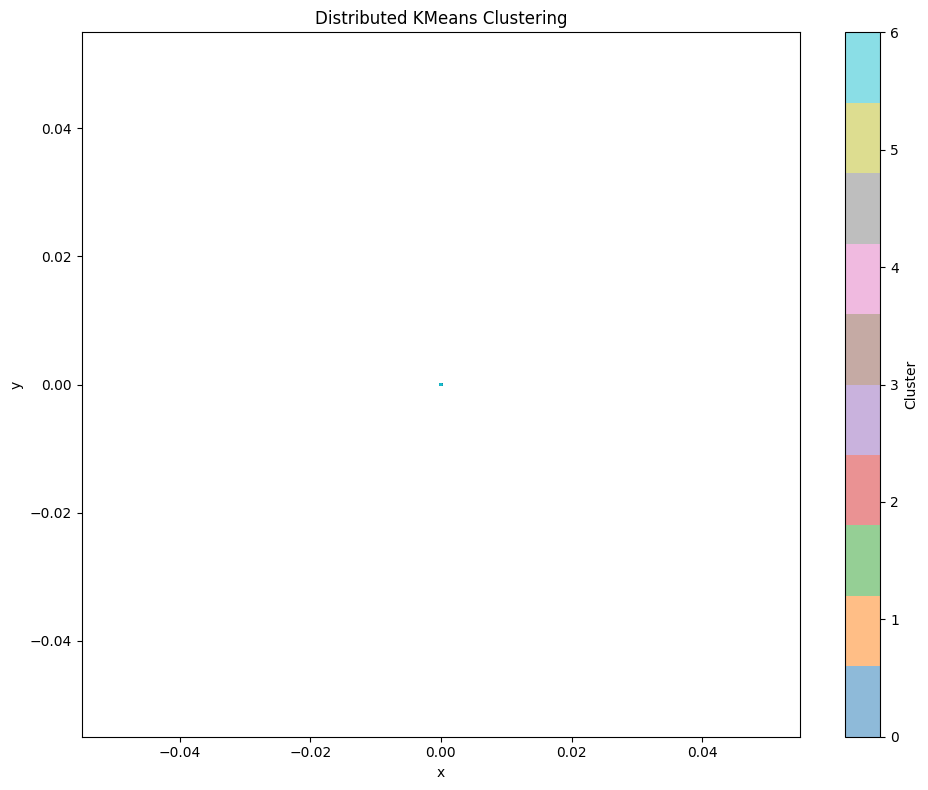

In [4]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(x, y, c=labels, cmap="tab10", s=1, alpha=0.5)
# plt.scatter(centroids[:, 0], centroids[:, 1], c="red", marker="X", s=200, edgecolors="black", linewidths=1.5, zorder=5)
plt.colorbar(scatter, label="Cluster")
plt.title("Distributed KMeans Clustering")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()